# One month of airport climate

Use NOAA Global Summary of the Month (GSOM) to inspect May 2024 precipitation
and mean temperature at Will Rogers World Airport in Oklahoma City. This
example requires `usdata` v0.7 or newer.

**Saved outputs are a recorded run**, with execution times and source
provenance below. Restart the kernel and run all cells to run it yourself.
See [examples setup](https://usdata.dev/examples/) for the optional notebook environment.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

import usdata
from usdata.pull import pull, verify

manifest = Path("examples/monthly-climate/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")

pd.set_option("display.max_rows", 8)
pd.set_option("display.max_columns", 8)
print(f"Executed (UTC): {datetime.now(UTC).isoformat(timespec='seconds')}")
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-09T00:11:42+00:00
usdata 0.7.0; pandas 3.0.5


## 1. Declare the input

The bundled manifest selects one station, one month, and two variables.
`units: metric` requests precipitation in millimeters and temperature in
degrees Celsius. All UTC calendar months touched by a GSOM query are selected
in full: May 6–7 still selects May, and May 31–June 1 selects both months.

In [2]:
print(manifest.read_text())

name: okc-monthly-climate
sources:
  - dataset: noaa:gsom
    start: 2024-05-01
    end: 2024-05-31
    variables: [PRCP, TAVG]
    params:
      stations: USW00013967
      units: metric



## 2. Pull and open

The first pull writes a lockfile next to the manifest. Later pulls reuse its
pinned URLs and checksums. `DATE` stays a `YYYY-MM` string unless you explicitly
parse it; each row represents a complete month. NCEI does not include an ERDDAP-style
units row, so the units here come from the manifest's documented `metric` setting.

In [3]:
result = pull(manifest)
items = result.fetched
(item,) = items
frame = item.open()
display(frame[["STATION", "DATE", "PRCP", "TAVG"]])

,STATION,DATE,PRCP,TAVG
0,USW00013967,2024-05,91.8,21.7


In [4]:
for item in items:
    print(f"{item.asset.dataset_id}")
    print(f"Retrieved (UTC): {item.provenance.retrieved_at.isoformat()}")
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print(f"Checksum: {item.provenance.checksum}")
    display(Markdown(f"[Source request](<{item.provenance.source_url}>)"))

noaa:gsom
Retrieved (UTC): 2026-09-09T00:11:42.930094+00:00
Bytes: 135; cache hit: False
Checksum: sha256:a8ef33c3d551ea4a97f62ead7c5e91233495e2ac61497524fd8e6aa0828fc8c5


[Source request](<https://www.ncei.noaa.gov/access/services/data/v1?dataset=global-summary-of-the-month&stations=USW00013967&startDate=2024-05-01&endDate=2024-05-31&format=csv&units=metric&includeStationLocation=1&dataTypes=PRCP%2CTAVG>)

## 3. Summarize the observations

Precipitation is the monthly total; temperature is the monthly mean. They have
different units and appear on separate axes. A single month at a single station
cannot establish a climate trend. Missing measurements remain missing.

In [5]:
for _, row in frame.iterrows():
    print(
        f"{row['STATION']} {row['DATE']}: precipitation {row['PRCP']:.1f} mm; "
        f"mean temperature {row['TAVG']:.1f} °C"
    )

USW00013967 2024-05: precipitation 91.8 mm; mean temperature 21.7 °C


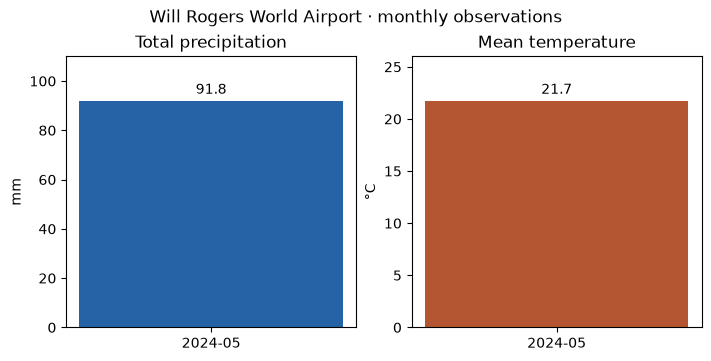

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), layout="constrained")
for ax, column, title, unit, color in zip(
    axes,
    ["PRCP", "TAVG"],
    ["Total precipitation", "Mean temperature"],
    ["mm", "°C"],
    ["#2563a6", "#b45631"],
    strict=True,
):
    bars = ax.bar(frame["DATE"], frame[column], color=color, width=0.5)
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set(title=title, ylabel=unit)
    ax.margins(y=0.2)
fig.suptitle("Will Rogers World Airport · monthly observations")
plt.show()

## 4. Verify and reuse

Verification checks the manifest and cached bytes against the lockfile. A repeat
pull uses that lockfile and cache. In your own analysis repository, keep both the
manifest and lockfile; preserve cached bytes for long-term reproducibility.
The SDK checkout ignores generated example lockfiles.

To explore another month, edit `dataset.yaml` and deliberately call
`pull(manifest, force=True)` to replace the lockfile, then rerun the later cells.
Without `force`, editing a locked manifest is reported as an input change.

In [7]:
drift = verify(manifest)
assert not drift, drift
again = pull(manifest)
print(f"Verification passed: {not drift}")
print(f"Restored from lockfile: {again.from_lockfile}")
print(f"All assets came from cache: {all(value.from_cache for value in again.fetched)}")

Verification passed: True
Restored from lockfile: True
All assets came from cache: True
